In [1]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
p = "data/raw/olist/"
OUT = "module_3_olist/outputs/"

mql    = pd.read_csv(p + "olist_marketing_qualified_leads_dataset.csv", parse_dates=["first_contact_date"])
deals  = pd.read_csv(p + "olist_closed_deals_dataset.csv", parse_dates=["won_date"])
items  = pd.read_csv(p + "olist_order_items_dataset.csv")
orders = pd.read_csv(p + "olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
print(mql.shape, deals.shape, items.shape, orders.shape)

(8000, 4) (842, 14) (112650, 7) (99441, 8)


In [2]:
print("MQL ids unique:", mql.mql_id.is_unique)
print("Deal mql_ids unique:", deals.mql_id.is_unique)
print("Deals whose mql_id is NOT in the MQL file:", (~deals.mql_id.isin(mql.mql_id)).sum())
print("Deal sellers found in order data:", deals.seller_id.isin(items.seller_id).sum(), "of", len(deals))
print("MQL dates:", mql.first_contact_date.min().date(), "to", mql.first_contact_date.max().date())
print("Won dates:", deals.won_date.min().date(), "to", deals.won_date.max().date())
print("Order dates:", orders.order_purchase_timestamp.min().date(), "to", orders.order_purchase_timestamp.max().date())
print("\nLeads by origin:\n", mql.origin.value_counts(dropna=False))

MQL ids unique: True
Deal mql_ids unique: True
Deals whose mql_id is NOT in the MQL file: 0
Deal sellers found in order data: 380 of 842
MQL dates: 2017-06-14 to 2018-05-31
Won dates: 2017-12-05 to 2018-11-14
Order dates: 2016-09-04 to 2018-10-17

Leads by origin:
 origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
NaN                    60
Name: count, dtype: int64


In [3]:
delivered = orders[orders.order_status == "delivered"][["order_id","order_purchase_timestamp"]]
sales = items.merge(delivered, on="order_id")

seller_rev = sales.groupby("seller_id").agg(
    revenue=("price","sum"),
    orders=("order_id","nunique"),
    first_sale=("order_purchase_timestamp","min"))

f = (mql.merge(deals, on="mql_id", how="left")
        .merge(seller_rev, left_on="seller_id", right_index=True, how="left"))

f["origin"]       = f.origin.fillna("unknown")
f["closed"]       = f.seller_id.notna()
f["revenue"]      = f.revenue.fillna(0)
f["orders"]       = f.orders.fillna(0)
f["activated"]    = f.revenue > 0
f["days_to_close"]= (f.won_date - f.first_contact_date).dt.days

f.to_parquet("data/processed/olist_funnel.parquet", index=False)
print(f.shape)
f[["mql_id","origin","closed","activated","revenue","days_to_close"]].head()

(8000, 23)


,mql_id,origin,closed,activated,revenue,days_to_close
0,dac32acd4db4c29c230538b72f8dd87d,social,False,False,0.0,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,paid_search,False,False,0.0,NaN
2,b4bc852d233dfefc5131f593b538befa,organic_search,False,False,0.0,NaN
3,6be030b81c75970747525b843c1ef4f8,email,False,False,0.0,NaN
4,5420aad7fec3549a85876ba1c529bd84,organic_search,True,True,858.0,5.0


In [4]:
n_mql, n_deal, n_act = len(f), f.closed.sum(), f.activated.sum()
print(f"""
Leads (MQLs):          {n_mql:,}
Closed deals:          {n_deal:,}   ({n_deal/n_mql:.1%} of leads)
Activated sellers:     {n_act:,}   ({n_act/n_deal:.1%} of deals, {n_act/n_mql:.1%} of leads)
Total revenue:         R$ {f.revenue.sum():,.0f}
Revenue per lead:      R$ {f.revenue.sum()/n_mql:,.2f}
Revenue per activated: R$ {f.loc[f.activated,'revenue'].mean():,.2f}
Median days to close:  {f.days_to_close.median():.0f}
""")


Leads (MQLs):          8,000
Closed deals:          842   (10.5% of leads)
Activated sellers:     376   (44.7% of deals, 4.7% of leads)
Total revenue:         R$ 664,858
Revenue per lead:      R$ 83.11
Revenue per activated: R$ 1,768.24
Median days to close:  14



In [5]:
data_end = delivered.order_purchase_timestamp.max()
f["days_observable"] = (data_end - f.won_date).dt.days
print("Order data ends:", data_end.date())
print(f.loc[f.closed, "days_observable"].describe().round(0))
print("Deals won with < 60 days of sales data left:", (f.days_observable < 60).sum())

Order data ends: 2018-08-29
count    842.0
mean     128.0
std       66.0
min      -78.0
25%       99.0
50%      137.0
75%      175.0
max      267.0
Name: days_observable, dtype: float64
Deals won with < 60 days of sales data left: 120


In [6]:
o = f.groupby("origin").agg(
    leads=("mql_id","count"),
    deals=("closed","sum"),
    activated=("activated","sum"),
    revenue=("revenue","sum"),
    median_days_to_close=("days_to_close","median"))
o["lead_share_%"]    = o.leads / o.leads.sum() * 100
o["revenue_share_%"] = o.revenue / o.revenue.sum() * 100
o["lead_to_deal_%"]  = o.deals / o.leads * 100
o["activation_%"]    = o.activated / o.deals.where(o.deals > 0) * 100
o["revenue_per_lead"]= o.revenue / o.leads
o = o.sort_values("leads", ascending=False).round(2)
o.to_csv(OUT + "origin_scorecard.csv")
o

,leads,deals,activated,revenue,median_days_to_close,lead_share_%,revenue_share_%,lead_to_deal_%,activation_%,revenue_per_lead
origin,,,,,,,,,,
organic_search,2296,271,111,204509.79,14.0,28.70,30.76,11.80,40.96,89.07
paid_search,1586,195,100,151444.15,15.0,19.82,22.78,12.30,51.28,95.49
social,1350,75,31,43394.20,30.0,16.88,6.53,5.56,41.33,32.14
unknown,1159,193,84,210893.97,11.0,14.49,31.72,16.65,43.52,181.96
direct_traffic,499,56,31,21852.90,10.0,6.24,3.29,11.22,55.36,43.79
email,493,15,6,8484.99,21.0,6.16,1.28,3.04,40.00,17.21
referral,284,24,9,16578.25,18.5,3.55,2.49,8.45,37.50,58.37
other,150,4,2,6776.75,9.0,1.88,1.02,2.67,50.00,45.18
display,118,6,2,923.00,8.5,1.48,0.14,5.08,33.33,7.82


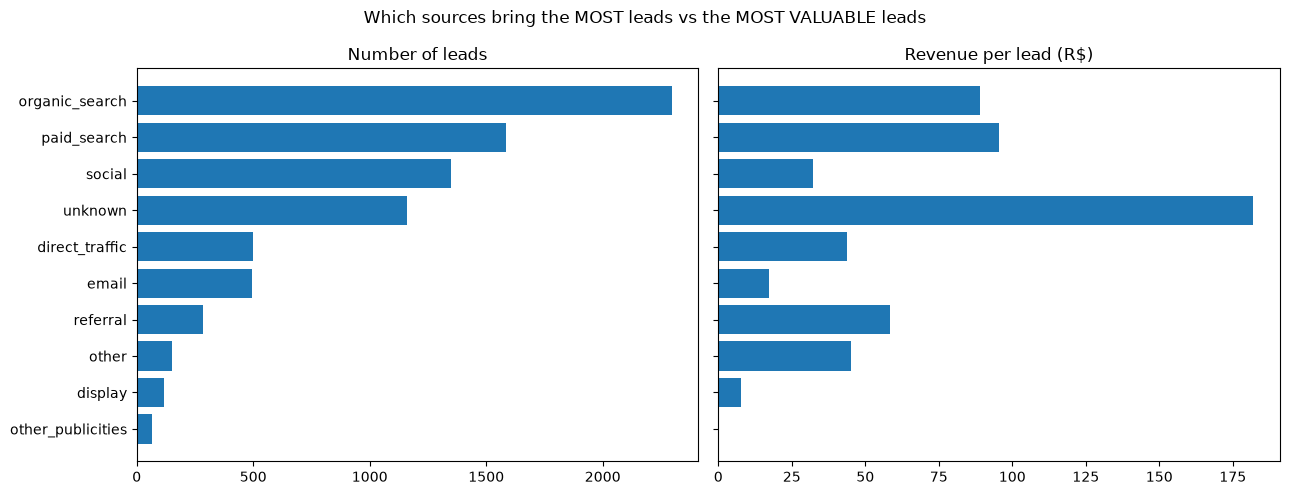

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
order = o.sort_values("leads").index
axes[0].barh(order, o.loc[order, "leads"]);            axes[0].set_title("Number of leads")
axes[1].barh(order, o.loc[order, "revenue_per_lead"]); axes[1].set_title("Revenue per lead (R$)")
plt.suptitle("Which sources bring the MOST leads vs the MOST VALUABLE leads")
plt.tight_layout(); plt.savefig(OUT + "leads_vs_value.png", dpi=150); plt.show()

In [8]:
big = o[o.leads >= 100]
print(f"""
Most leads:            {o.leads.idxmax()} ({o.leads.max():,} leads)
Best revenue per lead: {big.revenue_per_lead.idxmax()} (R$ {big.revenue_per_lead.max():,.2f})  [sources with ≥100 leads]
Worst revenue per lead:{big.revenue_per_lead.idxmin()} (R$ {big.revenue_per_lead.min():,.2f})
Best lead→deal rate:   {big['lead_to_deal_%'].idxmax()} ({big['lead_to_deal_%'].max():.1f}%)
Best activation rate:  {big['activation_%'].idxmax()} ({big['activation_%'].max():.1f}%)
""")


Most leads:            organic_search (2,296 leads)
Best revenue per lead: unknown (R$ 181.96)  [sources with ≥100 leads]
Worst revenue per lead:display (R$ 7.82)
Best lead→deal rate:   unknown (16.6%)
Best activation rate:  direct_traffic (55.4%)



In [9]:
# done